In [ ]:
list.files("/content")

[1] "ecommerce.csv" "sample_data"

In [ ]:
df <- read.csv("/content/ecommerce.csv")

In [ ]:
df

date,ecommerce_sales,wage,employment_rate,cpi
<chr>,<int>,<dbl>,<dbl>,<dbl>
2017-01,1236885,967.02,61.4,130.1
2017-02,1212033,964.51,61.5,129.9
2017-03,1255537,966.94,61.6,129.7
2017-04,1281690,971.17,61.6,130.1
2017-05,1262875,970.08,61.6,129.9
2017-06,1276594,972.01,61.8,129.9
2017-07,1363496,970.21,61.9,130.1
2017-08,1354108,976.68,61.8,130.4
2017-09,1323923,985.80,61.8,130.7


Test the joint significance of your model at a 95% confidence level. That is, calculate and interpret the F statistics.?

Make the hypothesis where:

Null hypothesis where Employment, wages, and CPI have no joint effect on e-commerce sales.

Alternative hyphotesis: At least one cofficient is not zero

In [ ]:
# Estimate linear regression model
model <- lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(model)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


Approximately 91.4% of the variation in retail e-commerce sales is explained by wages, employment rate, and CPI.
Intrepretation of each value individually:
- Wage pvalue < 2e-16, by every 1 $ increase, E-commerce sales increase by 19799. So if increase by 100, (100*19799)= 1,979,900
- Employment rate Pvalue = 0.833 which is > 0.05 (Not statistically significant.), After controlling for wages and inflation, employment rate does not have an independent measurable effect in this model (after controlling for wages and CPI)
- CPI, for each one unit increase of the inflation relative to the base year, the ecommerce decrease by 96900


In [ ]:
# Extract F-statistic
f_stat <- summary(model)$fstatistic
f_stat

value    numdf    dendf 
364.0718   3.0000 103.0000

In [ ]:
#p-value
p_value <- pf(f_stat[1], f_stat[2], f_stat[3], lower.tail = FALSE)
p_value

value 
1.161345e-54

- This gives the probability of observing such an F-statistic under H₀.

- At level of confidence 95%, Alpha (1-0.95)= 0.05

- P value < 0.05 which means reject H0 and the independent variables of wages, employment rate and CPI has signigicant effect on the E-commerce sale. Economic conditions (wages, employment, and inflation) are strongly associated with online spending in Canada.

- The regression model performs significantly better than a model with no predictors.

An F-statistic of 364 is very large.

Typical significant models might have F = 5, 10, 20. 364 indicates:

- Very strong joint explanatory power
- Likely high R²
- Strong macro trend relationships


The F-statistic for the regression model is 364.07 with 3 and 103 degrees of freedom. The corresponding p-value is 1.16 × 10⁻⁵⁴, which is far below the 5% significance level. Therefore, we reject the null hypothesis that all slope coefficients are jointly equal to zero. This indicates that wages, employment, and CPI are jointly statistically significant determinants of retail e-commerce sales in Canada. The large magnitude of the F-statistic suggests that the model has strong explanatory power.

Having very high F-statistic could partly reflect:

Trending variables

- Potential autocorrelation

- Possible non-stationarity

This does NOT invalidate the F-test — but it means:

- You must carefully check:

- Autocorrelation (Durbin-Watson / Breusch-Godfrey)

- Heteroskedasticity

- Possibly log transformation

Evaluate the model fit using Risduals vs actual data

In [ ]:
model <- lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(model)
ecommresd = resid(model)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


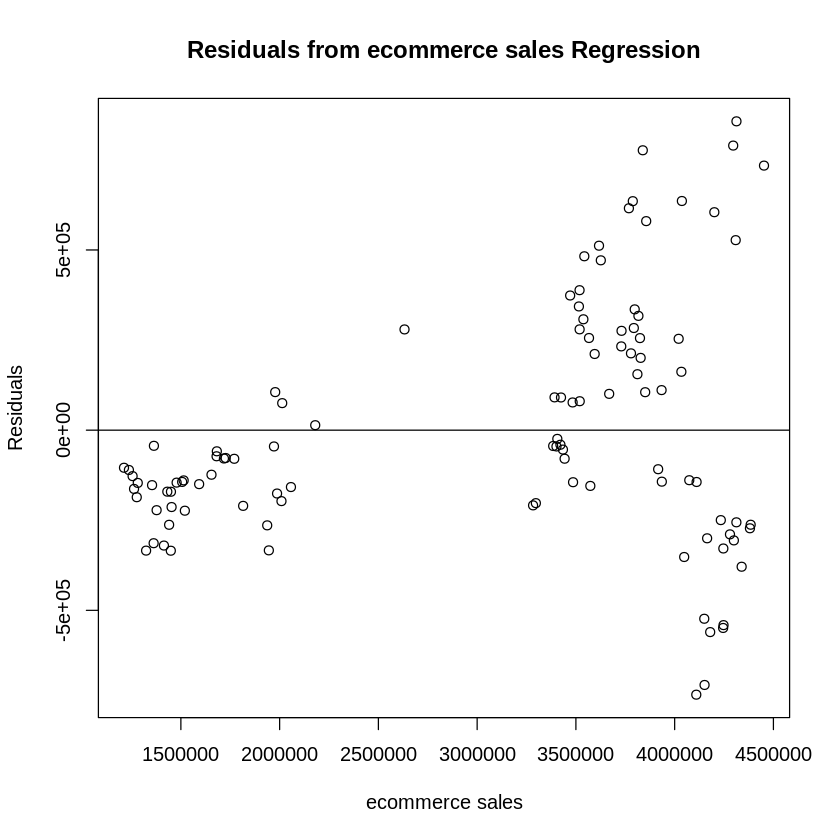

In [ ]:
plot(x = df$ecommerce_sales, y = ecommresd, xlab = "ecommerce sales",
	ylab = "Residuals", main = "Residuals from ecommerce sales Regression")
  abline(0, 0)

**What can you say about heteroskedasticity in your model? Plot the residuals of your model and conduct the necessary test to identify the presence of this problem.**

We usually assume that the error term is constant during OLS estimation. That is, we assume there’s a constant amount of “randomness” in the real world that affects Poverty Rate over time.

Heteroskedasticity describes the situation where the error term is not constant. More specifically, heteroskedasticity happens when the error term is distributed with unequal variance. For example, if the error is smaller for low values of minimum wage compared to high values of minimum wage.

Or, in mathematical terms: As the value of X changes, the spread or distribution of the error term  (which captures the gap between the actual observation and its predicted value) changes correspondingly.

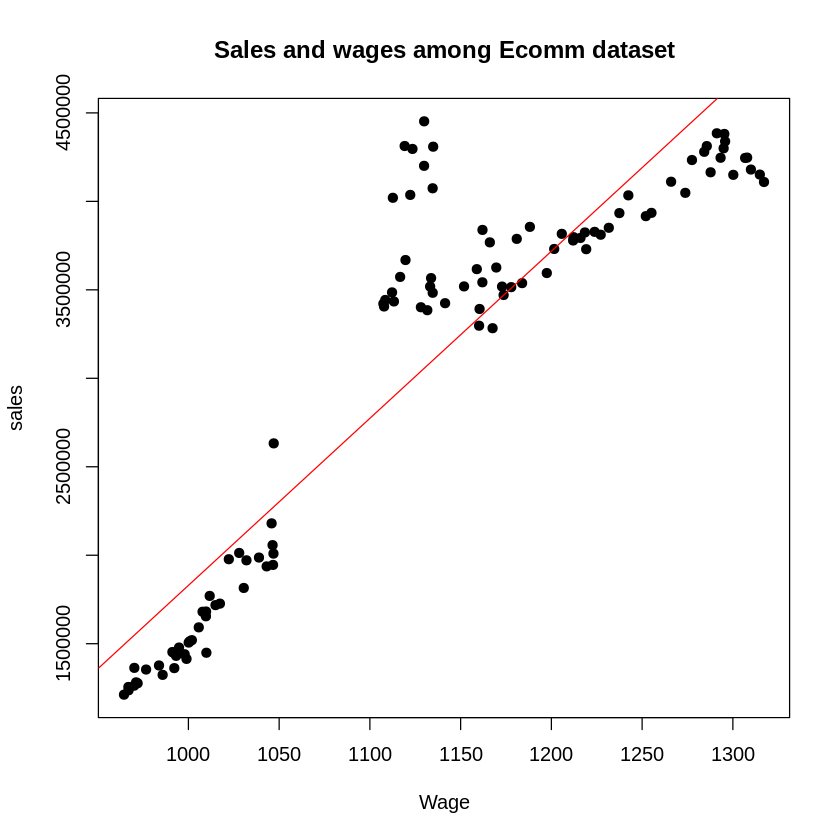

In [ ]:
plot(df$wage, df$ecommerce_sales, main="Sales and wages among Ecomm dataset",
	xlab="Wage", ylab="sales", pch=19)
abline(lm(df$ecommerce_sales~df$wage), col="red") # regression line (y~x)



Generally as the weekly earning increase, the spending on E-commerce increases as people have more purchasing power.the gap between the regression line and the observed data gets bigger between 1080 to 1030 then gets close on the regresssion line from 1150 to 1200 then get disparsed after 1200

**Bruesh-Pagan Method**

Null (H0): The residuals are distributed with equal variance (homoskedastic)

Alternative (HA): The residuals are distributed with unequal variance (heteroskedastic)

In [ ]:
install.packages("lmtest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’




In [ ]:
library(lmtest)
lm.Data2 = lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(lm.Data2)
bptest(lm.Data2)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16



	studentized Breusch-Pagan test

data:  lm.Data2
BP = 13.853, df = 3, p-value = 0.003112


The P-value of 0.003112< 0.05 (Alpha), so we reject the null hypotheseis, and the model has unequall variance.

As we have heteroskedastic proplem, we will look at it



**Report the Robust standard error of your model. Do you think this has fixed any heteroskedasticity problem in your model?**

Due to the absense of heteroskedasticity problem
Adjust the standard errors of coffient estimates
Using the feasible generalized least squre(FGLS) makes the residuals of a model more similar to one another (reduces the variance of the errors) by:


In [ ]:
install.packages("lmtest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’




In [ ]:
library(lmtest)
lm.Data3 = lm (formula = ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(lm.Data3)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


In [ ]:
install.packages("sandwich")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(sandwich)
coeftest(lm.Data3, vcov = vcovHC(lm.Data3, type = "HC0"))


t test of coefficients:

                  Estimate Std. Error t value  Pr(>|t|)    
(Intercept)     -4747373.7  1390391.3 -3.4144 0.0009154 ***
wage               19799.0     2129.0  9.2998 2.666e-15 ***
employment_rate    -7241.5    27920.8 -0.2594 0.7958771    
cpi               -96899.6    19517.0 -4.9649 2.734e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
#This is regression with robust se
lm.Data3 = lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(lm.Data3)
coeftest(lm.Data3, vcov = vcovHC(lm.Data3, type = "HC0"))


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16



t test of coefficients:

                  Estimate Std. Error t value  Pr(>|t|)    
(Intercept)     -4747373.7  1390391.3 -3.4144 0.0009154 ***
wage               19799.0     2129.0  9.2998 2.666e-15 ***
employment_rate    -7241.5    27920.8 -0.2594 0.7958771    
cpi               -96899.6    19517.0 -4.9649 2.734e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


To address potential heteroskedasticity, robust standard errors were estimated using the HC0 estimator from the sandwich package. As expected, the coefficient estimates remain unchanged, since heteroskedasticity does not bias OLS coefficients. However, the standard errors differ slightly from the original OLS estimates. For example, the standard error of the wage variable increased from 1,971 to 2,129, while the standard error of the CPI variable increased from 17,744 to 19,517. Despite these adjustments, the statistical significance of the variables remains largely unchanged: wages and CPI remain statistically significant at the 1% level, while the employment rate remains insignificant. This suggests that although heteroskedasticity may be present, it does not substantially affect the conclusions of the model.

Interpretation of wage

- The standard error increased, which reduced the t-statistic.
- This means the original OLS slightly overstated the precision of the wage estimate.
- Robust SE corrected this by providing a more realistic estimate of the variability of the coefficient.
- However, wage remains highly significant, so the inference does not change.

Interpretation of employment rate

- Employment rate was insignificant in both models, meaning robust SE does not change the inference.

Interpretation of CPI

- Standard error increased

- t-statistic decreased slightly

- OLS overestimated precision.

- Robust SE corrects the variance estimate, producing more reliable hypothesis tests.

- But CPI remains statistically significant.

Final intrepretation

To address potential heteroskedasticity, robust standard errors were estimated using the sandwich estimator. The coefficient estimates remain unchanged, but the standard errors differ slightly from the original OLS estimates. For example, the standard error for the wage variable increased from 1,971 to 2,129, while the CPI standard error increased from 17,744 to 19,517. These changes slightly reduce the t-statistics but do not alter the overall inference: wages and CPI remain statistically significant determinants of e-commerce sales, while the employment rate remains insignificant. Robust standard errors do not eliminate heteroskedasticity in the model; rather, they correct the estimated variance of the coefficients so that hypothesis tests and p-values remain valid even when heteroskedasticity is present.

**What about autocorrelation? Do you think your model suffers from this? Conduct the necessary tests.**

OLS estimation assumes that error is constant, and specifically that:

- The expected value of the error term must be zero.
- The error at one point in time is not correlated with the error at a previous point in time.

In [ ]:
# Install packages if needed
install.packages("ggplot2")
install.packages("lmtest")

# Load libraries
library(ggplot2)
library(lmtest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [ ]:
# Run the regression model
model <- lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)

# View summary
summary(model)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


In [ ]:
# Extract residuals
df$residuals <- resid(model)

In [ ]:
str(df$date)

 chr [1:107] "2017-01" "2017-02" "2017-03" "2017-04" "2017-05" "2017-06" ...


In [ ]:
install.packages("scales")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(scales)

In [ ]:
head(df$date)

[1] "2017-01" "2017-02" "2017-03" "2017-04" "2017-05" "2017-06"

In [ ]:
df$date <- as.Date(paste0(df$date, "-01"), format="%Y-%m-%d")

In [ ]:
str(df$date)

 Date[1:107], format: "2017-01-01" "2017-02-01" "2017-03-01" "2017-04-01" "2017-05-01" ...


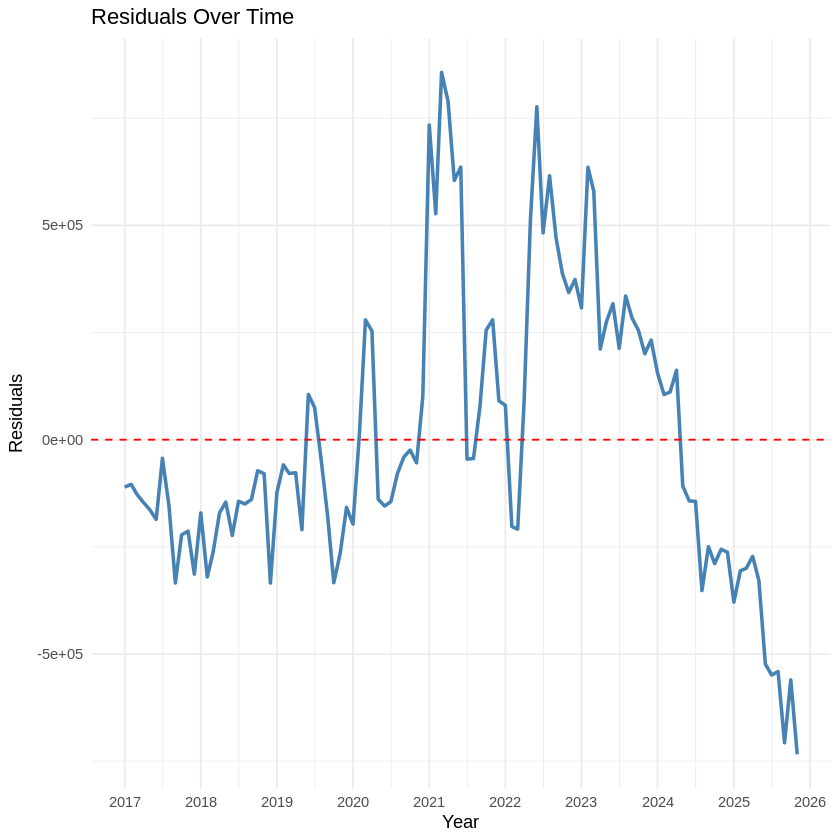

In [ ]:
ggplot(df, aes(x = date, y = residuals)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
  labs(
    title = "Residuals Over Time",
    x = "Year",
    y = "Residuals"
  ) +
  theme_minimal()

The data is spiky and random from 2017 to 2021, then drastic upward trend from 2020 to the first half of 2021 followed by big drop then a drastic rise in 2022, then the data Smoothly moving downward, then the data is negatively autocorrelated.

**Autocorrelation Function**
Let’s use the acf function in R to see the correlation between residuals and their lags.

In [ ]:
lm.Data6 = lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(lm.Data6)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


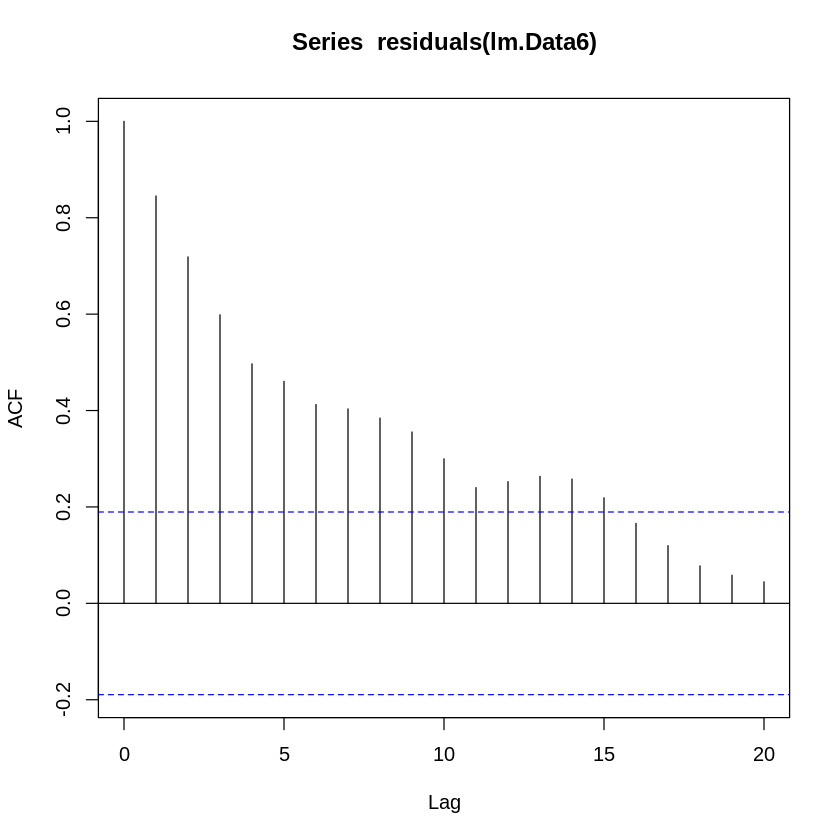

In [ ]:
acf(residuals(lm.Data6))

The ACF plot shows that autocorrelation decreases as the lag increases, meaning observations that are closer in time are more correlated than those further apart. This suggests that the effect of past values gradually diminishes over time. Since this pattern appears in the residuals, it indicates that some temporal dependence may still exist and the model may not fully capture the time-series structure.

**Durbin-Watson Test for Autocorrelation**

- Null: no correlation among a model’s residuals
- Alternative: the model’s residuals are autocorrelated

In [ ]:
lm.Datatest = lm(ecommerce_sales ~ wage + employment_rate + cpi, data = df)
summary(lm.Datatest)


Call:
lm(formula = ecommerce_sales ~ wage + employment_rate + cpi, 
    data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-734010 -209414  -79258  222735  856915 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4747374    1857011  -2.556    0.012 *  
wage               19799       1971  10.044  < 2e-16 ***
employment_rate    -7242      34270  -0.211    0.833    
cpi               -96900      17744  -5.461  3.3e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 335100 on 103 degrees of freedom
Multiple R-squared:  0.9138,	Adjusted R-squared:  0.9113 
F-statistic: 364.1 on 3 and 103 DF,  p-value: < 2.2e-16


In [ ]:
dwtest(lm.Datatest)


	Durbin-Watson test

data:  lm.Datatest
DW = 0.26228, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


The P-value is less than 0.05, we must reject the null hypothesis. This means that we have statistically significant evidence of autocorrelation for the residuals in our E-commerce sales model.

At the 95% confidence level, the Durbin–Watson test strongly rejects the null hypothesis of no autocorrelation (DW = 0.262, p-value < 2.2e-16). This indicates significant positive autocorrelation in the residuals, meaning the errors are correlated over time. Therefore, the regression model violates the independence assumption of the error terms, suggesting that the model may be misspecified or that time-series effects have not been fully accounted for.

**Estimate a Log-Log model and interpret the coefficients.**
We can set up a log-log model for Poverty Rate by taking the natural log of the variables in the levels model:

In [ ]:
lm.logData1 = lm(log(ecommerce_sales) ~ log(wage) + log(employment_rate) + log(cpi), data = df)
summary(lm.logData1)


Call:
lm(formula = log(ecommerce_sales) ~ log(wage) + log(employment_rate) + 
    log(cpi), data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.273421 -0.100092 -0.002046  0.102110  0.290042 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -22.9822     4.0887  -5.621 1.63e-07 ***
log(wage)              9.4295     0.8281  11.387  < 2e-16 ***
log(employment_rate)   0.7651     0.7680   0.996    0.322    
log(cpi)              -6.3398     0.9712  -6.528 2.56e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1311 on 103 degrees of freedom
Multiple R-squared:  0.9154,	Adjusted R-squared:  0.9129 
F-statistic: 371.5 on 3 and 103 DF,  p-value: < 2.2e-16


A 1% increase in the weekly earning is leading to 9.4% increase in e-commerce sales.
A 1% increase in employment rate leads to about 0.77% increase in e-commerce sales.
A 1% increase in CPI leads to approximately a 6.34% decrease in e-commerce sales, holding other variables constant.

**Add fixed effects to your model. Interpret.**
If we don’t have enough data across a geographical region (such as all of the provinces), the coefficient estimates might represent an effect that’s only relevant to specific jurisdictions.

In [ ]:
install.packages("plm")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘miscTools’, ‘rbibutils’, ‘bdsmatrix’, ‘collapse’, ‘zoo’, ‘sandwich’, ‘lmtest’, ‘maxLik’, ‘Rdpack’, ‘Formula’




In [ ]:
str(df$date)

 chr [1:107] "2017-01" "2017-02" "2017-03" "2017-04" "2017-05" "2017-06" ...


In [ ]:
df$date <- as.Date(paste0(df$date, "-01"), format="%Y-%m-%d")

In [ ]:
str(df$date)

 Date[1:107], format: "2017-01-01" "2017-02-01" "2017-03-01" "2017-04-01" "2017-05-01" ...


In [ ]:
df$year <- as.numeric(format(df$date, "%Y"))
df$month <- as.numeric(format(df$date, "%m"))

In [ ]:
head(df[,c("date","year","month")])

,date,year,month
,<date>,<dbl>,<dbl>
1,2017-01-01,2017,1
2,2017-02-01,2017,2
3,2017-03-01,2017,3
4,2017-04-01,2017,4
5,2017-05-01,2017,5
6,2017-06-01,2017,6


In [ ]:
library(plm)
pdata <- pdata.frame(df, index = c("year","month"))

In [ ]:
pdata

,date,ecommerce_sales,wage,employment_rate,cpi,year,month
,<date>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
2017-1,2017-01-01,1236885,967.02,61.4,130.1,2017,1
2017-2,2017-02-01,1212033,964.51,61.5,129.9,2017,2
2017-3,2017-03-01,1255537,966.94,61.6,129.7,2017,3
2017-4,2017-04-01,1281690,971.17,61.6,130.1,2017,4
2017-5,2017-05-01,1262875,970.08,61.6,129.9,2017,5
2017-6,2017-06-01,1276594,972.01,61.8,129.9,2017,6
2017-7,2017-07-01,1363496,970.21,61.9,130.1,2017,7
2017-8,2017-08-01,1354108,976.68,61.8,130.4,2017,8
2017-9,2017-09-01,1323923,985.80,61.8,130.7,2017,9


In [ ]:
fe_time_model <- lm((ecommerce_sales) ~ (wage) +
                    (employment_rate) +
                    (cpi) +
                    factor(year),
                    data = df)

summary(fe_time_model)


Call:
lm(formula = (ecommerce_sales) ~ (wage) + (employment_rate) + 
    (cpi) + factor(year), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-440198  -79623  -14631   85940  432770 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)       3660967    1881893   1.945 0.054687 .  
wage                11138       1575   7.074 2.55e-10 ***
employment_rate    -90958      20650  -4.405 2.78e-05 ***
cpi                -58280      16452  -3.542 0.000617 ***
factor(year)2018   113886      78862   1.444 0.151992    
factor(year)2019   344259     100883   3.412 0.000947 ***
factor(year)2020   662933     151952   4.363 3.26e-05 ***
factor(year)2021  1377576     194029   7.100 2.25e-10 ***
factor(year)2022  1349587     277996   4.855 4.73e-06 ***
factor(year)2023  1492205     346610   4.305 4.06e-05 ***
factor(year)2024  1321476     404062   3.270 0.001497 ** 
factor(year)2025  1153294     451375   2.555 0.012205 *  
---
Signif. codes:  0 ‘***’ 0.

The data likely contains seasonality such as:

- Holiday shopping spikes

- Black Friday / Christmas sales

- summer slowdowns

- Month fixed effects capture this.

Without them, the regression may incorrectly attribute seasonal sales spikes to wage or CPI.